In [3]:
# Librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Para la regresión lineal:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Para subir los archivos desde drive
from google.colab import drive
drive.mount('/content/drive')
import glob

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#1. Cargar los archivos

In [44]:
# === 1. Cargar el archivo de referencia ===
datos_ref = pd.read_excel("/content/drive/MyDrive/Metodos/datos/Datos Estaciones AMB.xlsx")
datos_ref = datos_ref[["Date&Time", "PM2.5"]]
datos_ref = datos_ref.rename(columns={"Date&Time": "Fecha",
                                      "PM2.5": "Concentracion"})

# Convertir los valores de fecha
datos_ref["Fecha"] = pd.to_datetime(datos_ref["Fecha"], errors="coerce")
datos_ref["Fecha"] = datos_ref["Fecha"].dt.tz_localize(None)
datos_ref = datos_ref.sort_values("Fecha")

# === 2. Cargar y unir los 7 archivos del sensor ===
archivos_sensor = glob.glob("/content/drive/MyDrive/Metodos/datos/sensores/mediciones_*.csv")

lista_dfs = []
for archivo in archivos_sensor:
    df = pd.read_csv(archivo)
    df = df[["fecha_hora_med", "valor"]]
    df = df.rename(columns={"fecha_hora_med": "Fecha",
                            "valor": "Concentracion"})
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    df["Fecha"] = df["Fecha"].dt.tz_localize(None)
    lista_dfs.append(df)

# Unir todo en un solo DataFrame
datos_cal = pd.concat(lista_dfs, ignore_index=True)
datos_cal = datos_cal.sort_values("Fecha")

# Asegurar que la columna de concentracion es numérica
datos_ref["Concentracion"] = pd.to_numeric(datos_ref["Concentracion"], errors="coerce")
datos_ref = datos_ref.dropna(subset=["Concentracion"])
datos_cal["Concentracion"] = pd.to_numeric(datos_cal["Concentracion"], errors="coerce")
datos_cal = datos_cal.dropna(subset=["Concentracion"])

# === 3. Confirmar tamaños ===
print(f"Datos referencia: {len(datos_ref)} registros")
print(f"Datos calibrar (7 sensores unidos): {len(datos_cal)} registros")

Datos referencia: 7921 registros
Datos calibrar (7 sensores unidos): 5009 registros


#2. Distancias por ventana

In [65]:
def distancias_por_ventana(ref, cal, ventanas):
    """
    Calcula la distancia euclídea entre ref y cal para varias ventanas de resampleo.

    Parámetros:
      ref, cal : DataFrames con columnas ["Fecha", "Concentracion"]
      ventanas : lista de strings de ventanas pandas (ej. ["1h", "3h", "6h"])

    Retorna:
      DataFrame con columnas [Ventana, Distancia, N_datos]
    """
    resultados = []

    for ventana in ventanas:
        # Resampleo por ventana
        ref_res = ref[["Fecha", "Concentracion"]].resample(ventana, on="Fecha").mean().dropna()
        cal_res = cal[["Fecha", "Concentracion"]].resample(ventana, on="Fecha").mean().dropna()

        # Unir por fechas comunes
        merged = pd.merge(ref_res, cal_res, left_index=True, right_index=True,
                          suffixes=("_ref", "_cal")).dropna()

        if len(merged) == 0:
            continue  # Saltar ventanas sin datos

        # Distancia euclídea
        dist = np.sqrt(np.sum((merged["Concentracion_ref"] - merged["Concentracion_cal"])**2))

        resultados.append((ventana, dist, len(merged)))

    return pd.DataFrame(resultados, columns=["Ventana", "Distancia", "N_datos"]).sort_values("Ventana")

ventanas = ["1h", "2h", "3h", "6h", "8h", "12h", "24h"]
df_distancias = distancias_por_ventana(datos_ref, datos_cal, ventanas).sort_values("Distancia")

print(df_distancias)


  Ventana   Distancia  N_datos
6     24h   83.230730      169
5     12h  123.647472      329
4      8h  157.218942      488
3      6h  188.049122      647
2      3h  287.852081     1282
1      2h  363.528195     1911
0      1h  548.421517     3791


#3. Calibración

### Calibración y errores por ventana

  Ventana     Alpha      RMSE  N_datos
6     24h  0.447662  1.514626      169
5     12h  0.424493  1.908504      329
4      8h  0.404829  2.169653      488
3      6h  0.390778  2.506934      647
2      3h  0.346302  2.958997     1282
1      2h  0.329434  3.122317     1911
0      1h  0.296445  3.432616     3791


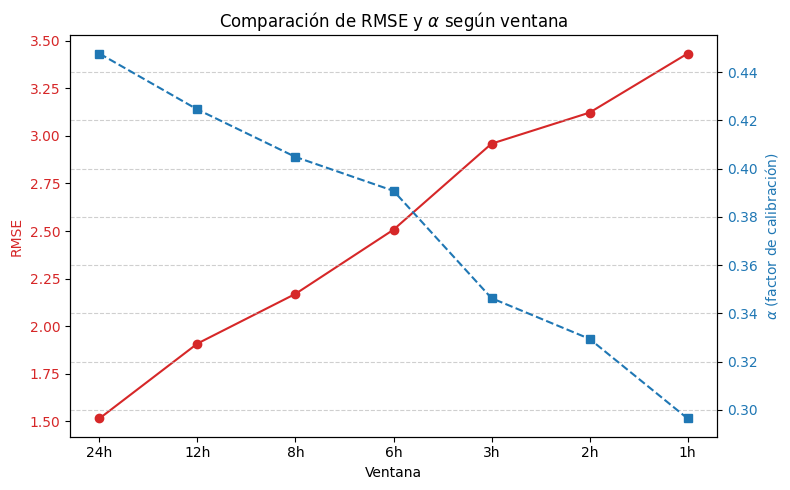

In [75]:
def evaluar_resampleo(ref, cal, ventanas):
    """
    Prueba varias ventanas de resampleo y devuelve los resultados de calibración.
    """
    resultados = []

    for ventana in ventanas:
        # Resampleo
        ref_res = ref[["Fecha", "Concentracion"]].resample(ventana, on="Fecha").mean().dropna()
        cal_res = cal[["Fecha", "Concentracion"]].resample(ventana, on="Fecha").mean().dropna()

        # Emparejar por fechas exactas
        merged = pd.merge(ref_res, cal_res, left_index=True, right_index=True,
                          suffixes=("_ref", "_cal")).dropna()

        if len(merged) == 0:
            continue  # Saltar ventanas sin datos

        # Ajuste lineal f_ref = α f_cal
        X = merged["Concentracion_cal"].values.reshape(-1, 1)
        y = merged["Concentracion_ref"].values
        modelo = LinearRegression().fit(X, y)

        alpha = modelo.coef_[0]
        y_pred = modelo.predict(X)
        rmse = np.sqrt(mean_squared_error(y, y_pred))

        resultados.append((ventana, alpha, rmse, len(merged)))

    # Pasar a DataFrame
    df_resultados = pd.DataFrame(resultados, columns=["Ventana", "Alpha", "RMSE", "N_datos"])
    return df_resultados.sort_values("RMSE")

# === Ejecutar comparación ===
ventanas = ["1h", "2h", "3h", "6h", "8h", "12h", "24h"]
df_resultados = evaluar_resampleo(datos_ref, datos_cal, ventanas)

print(df_resultados)

# === Gráfico RMSE vs Ventana ===
fig, ax1 = plt.subplots(figsize=(8,5))

# Eje izquierdo → RMSE
color = "tab:red"
ax1.set_xlabel("Ventana")
ax1.set_ylabel("RMSE", color=color)
ax1.plot(df_resultados["Ventana"], df_resultados["RMSE"],
         marker="o", linestyle="-", color=color, label="RMSE")
ax1.tick_params(axis="y", labelcolor=color)

# Eje derecho → Alpha
ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel(r"$\alpha$ (factor de calibración)", color=color)
ax2.plot(df_resultados["Ventana"], df_resultados["Alpha"],
         marker="s", linestyle="--", color=color, label="Alpha")
ax2.tick_params(axis="y", labelcolor=color)

# Título y rejilla
plt.title(r"Comparación de RMSE y $\alpha$ según ventana")
fig.tight_layout()
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("/content/drive/MyDrive/Metodos/figuras/calibracion_ventana")
plt.show()

### Gráficos de calibración

Distancia euclídea (1H): 548.422
Factor de calibración α = 0.296
Error RMSE del ajuste: 3.433


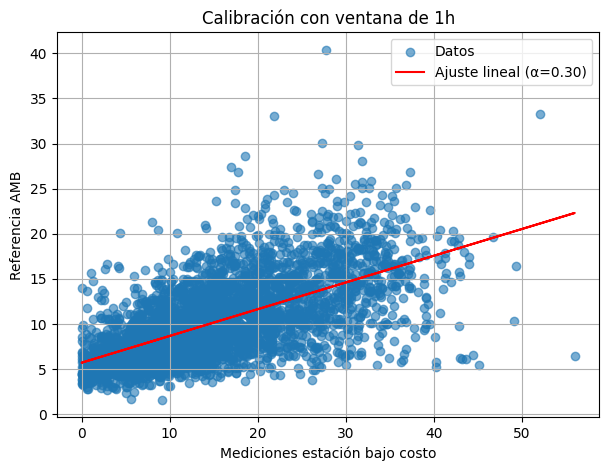

Distancia euclídea (24H): 83.231
Factor de calibración α = 0.448
Error RMSE del ajuste: 1.515


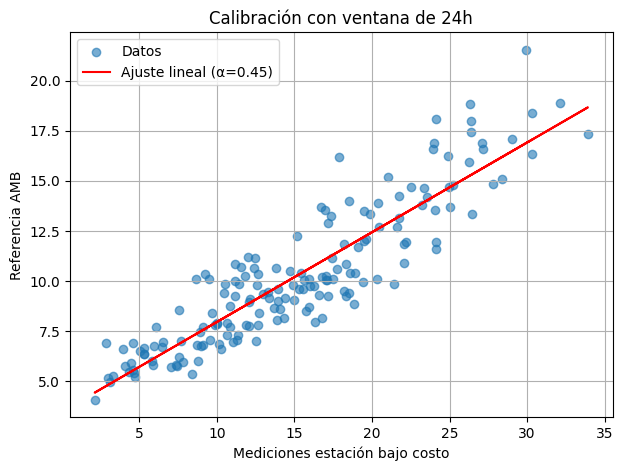

Distancia euclídea (1H): 560.719
Factor de calibración α = 0.290
Error RMSE del ajuste: 3.418


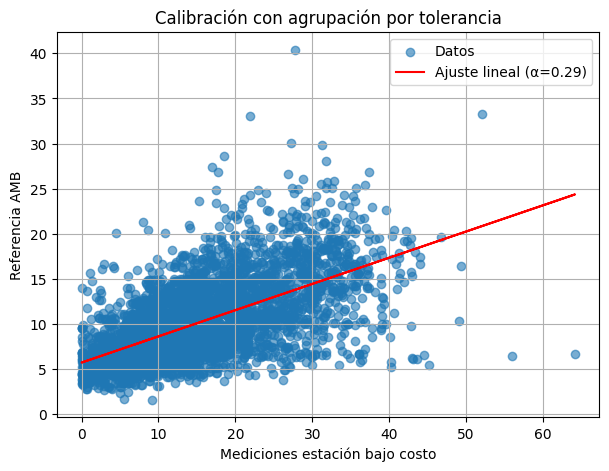

In [77]:
# === Funciones para calcular distancia con promedio móvil ===
def distancia_euclidea_resampleo(ref, cal, ventana="1h"):
    """
    Calcula la distancia euclídea entre promedios móviles de ref y cal.
    ventana: string de resampleo tipo pandas ('1H', '6H', '1D', etc.)
    """
    ref_res = ref[["Fecha", "Concentracion"]].resample(ventana, on="Fecha").mean().dropna()
    cal_res = cal[["Fecha", "Concentracion"]].resample(ventana, on="Fecha").mean().dropna()

    # Unir por fechas comunes
    merged = pd.merge(ref_res, cal_res, left_index=True, right_index=True,
                          suffixes=("_ref", "_cal")).dropna()

    # Distancia euclídea
    dist = np.sqrt(np.sum((merged["Concentracion_ref"] - merged["Concentracion_cal"])**2))
    return dist, merged

def distancia_euclidea_tolerancia(ref, cal, ventana="1h"):
    """
    Calcula la distancia euclídea entre promedios móviles de ref y cal.
    ventana: string de resampleo tipo pandas ('1H', '6H', '1D', etc.)
    """
    merged = pd.merge_asof(
        cal,
        ref,
        on="Fecha",
        suffixes=("_cal", "_ref"),
        direction="nearest",
        tolerance=pd.Timedelta("10min")
    ).dropna()

    # Calcular distancia euclídea
    dist = np.sqrt(np.sum((merged["Concentracion_ref"] - merged["Concentracion_cal"])**2))
    return dist, merged

# ==== Cálculo con ventana de 1 hora ====
dist, merged = distancia_euclidea_resampleo(datos_ref, datos_cal, ventana="1h")
print(f"Distancia euclídea (1H): {dist:.3f}")


# Ajuste lineal para calibración
X = merged["Concentracion_cal"].values.reshape(-1, 1)
y = merged["Concentracion_ref"].values

modelo = LinearRegression().fit(X, y)
alpha = modelo.coef_[0]
print(f"Factor de calibración α = {alpha:.3f}")

# Validación y alcance
y_pred = modelo.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"Error RMSE del ajuste: {rmse:.3f}")

# Gráfico de calibración
plt.figure(figsize=(7, 5))
plt.scatter(X, y, label="Datos", alpha=0.6)
plt.plot(X, y_pred, color="red", label=f"Ajuste lineal (α={alpha:.2f})")
plt.xlabel("Mediciones estación bajo costo")
plt.ylabel("Referencia AMB")
plt.title("Calibración con ventana de 1h")
plt.legend()
plt.grid()
plt.savefig("/content/drive/MyDrive/Metodos/figuras/calibracion_1h")
plt.show()


# ==== Cálculo con ventana de 24 horas ====
dist, merged = distancia_euclidea_resampleo(datos_ref, datos_cal, ventana="24h")
print(f"Distancia euclídea (24H): {dist:.3f}")

# Ajuste lineal para calibración
X = merged["Concentracion_cal"].values.reshape(-1, 1)
y = merged["Concentracion_ref"].values

modelo = LinearRegression().fit(X, y)
alpha = modelo.coef_[0]
print(f"Factor de calibración α = {alpha:.3f}")

# Validación y alcance
y_pred = modelo.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"Error RMSE del ajuste: {rmse:.3f}")

# Gráfico de calibración
plt.figure(figsize=(7, 5))
plt.scatter(X, y, label="Datos", alpha=0.6)
plt.plot(X, y_pred, color="red", label=f"Ajuste lineal (α={alpha:.2f})")
plt.xlabel("Mediciones estación bajo costo")
plt.ylabel("Referencia AMB")
plt.title("Calibración con ventana de 24h")
plt.legend()
plt.grid()
plt.savefig("/content/drive/MyDrive/Metodos/figuras/calibracion_24h")
plt.show()


# ==== Cálculo con agrupación por tolerancia ====
dist, merged = distancia_euclidea_tolerancia(datos_ref, datos_cal, ventana="1h")
print(f"Distancia euclídea (1H): {dist:.3f}")

# Ajuste lineal para calibración
X = merged["Concentracion_cal"].values.reshape(-1, 1)
y = merged["Concentracion_ref"].values

modelo = LinearRegression().fit(X, y)
alpha = modelo.coef_[0]
print(f"Factor de calibración α = {alpha:.3f}")

# Validación y alcance
y_pred = modelo.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"Error RMSE del ajuste: {rmse:.3f}")

# Gráfico de calibración
plt.figure(figsize=(7, 5))
plt.scatter(X, y, label="Datos", alpha=0.6)
plt.plot(X, y_pred, color="red", label=f"Ajuste lineal (α={alpha:.2f})")
plt.xlabel("Mediciones estación bajo costo")
plt.ylabel("Referencia AMB")
plt.title("Calibración con agrupación por tolerancia")
plt.legend()
plt.grid()
plt.savefig("/content/drive/MyDrive/Metodos/figuras/calibracion_tolerancia")
plt.show()